### Selection et Nettoyage des données

In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive')

input_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arboré_data_clean.csv"
output_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia.csv"

# Important : garde "N/A" comme texte
df = pd.read_csv(input_file, keep_default_na=False)

colonnes_utiles = [
    "haut_tot",
    "haut_tronc",
    "tronc_diam",
    "age_estim",
    "fk_stadedev",
    "fk_port",
    "fk_pied",
    "fk_situation",
    "fk_revetement",
    "feuillage"
]

df_ia = df.loc[:, df.columns.intersection(colonnes_utiles)]

df_ia.to_csv(output_file, index=False, encoding="utf-8")

print("Fichier créé :", output_file)
print("Colonnes gardées :", list(df_ia.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fichier créé : /content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia.csv
Colonnes gardées : ['haut_tot', 'haut_tronc', 'tronc_diam', 'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'age_estim', 'feuillage']


### Initilisation de la colonne "alerte"

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# =========================
# 1) Monter Google Drive
# =========================
drive.mount('/content/drive')

# =========================
# 2) Charger le CSV
# =========================
input_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia.csv"
output_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia_avec_alerte.csv"

df = pd.read_csv(input_file, keep_default_na=False)

# =========================
# 3) Conversion des colonnes numériques
# =========================
colonnes_numeriques = ["haut_tot", "haut_tronc", "tronc_diam", "age_estim"]

for col in colonnes_numeriques:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4) Normalisation légère du texte
# =========================
colonnes_textes = ["fk_stadedev", "fk_port", "fk_pied", "fk_situation", "fk_revetement", "feuillage"]

for col in colonnes_textes:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Remplacer les stades manquants par 'inconnu'
df["fk_stadedev"] = df["fk_stadedev"].replace({"": "inconnu", "n/a": "inconnu"})

# Statistiques par stade de développement
stats = df.groupby("fk_stadedev").agg(
    haut_mediane=("haut_tot", "median"),
    haut_q3=("haut_tot", lambda x: x.quantile(0.75)),
    diam_mediane=("tronc_diam", "median"),
    diam_q1=("tronc_diam", lambda x: x.quantile(0.25)),
    age_mediane=("age_estim", "median"),
    age_q3=("age_estim", lambda x: x.quantile(0.75))
).reset_index()

df = df.merge(stats, on="fk_stadedev", how="left")

# =========================
# 5) Création du score de risque
# =========================
score = pd.Series(0, index=df.index)

# Hauteur : plus haut que les arbres de même stade = plus de risque
score += np.where(df["haut_tot"] > df["haut_mediane"], 1, 0)
score += np.where(df["haut_tot"] > df["haut_q3"], 1, 0)

# Diamètre : plus fin que les arbres de même stade = plus de risque
score += np.where(df["tronc_diam"] < df["diam_mediane"], 1, 0)
score += np.where(df["tronc_diam"] < df["diam_q1"], 1, 0)

# Âge : plus vieux que les arbres de même stade = plus de risque
score += np.where(df["age_estim"] > df["age_mediane"], 1, 0)
score += np.where(df["age_estim"] > df["age_q3"], 1, 0)

# ---- Stade de développement
map_stadedev = {
    "jeune": 0,
    "adulte": 1,
    "vieux": 2,
    "senescent": 3,
    "n/a": 0
}
score += df["fk_stadedev"].map(map_stadedev).fillna(0)

# ---- Situation
map_situation = {
    "isolé": 2,
    "alignement": 1,
    "groupe": 0,
    "n/a": 0
}
score += df["fk_situation"].map(map_situation).fillna(0)

# ---- Revêtement
map_revetement = {
    "oui": 1,
    "non": 0,
    "n/a": 0
}
score += df["fk_revetement"].map(map_revetement).fillna(0)

# ---- Type de pied
map_pied = {
    "gazon": 0,
    "terre": 0,
    "végétation": 0,
    "bande de terre": 1,
    "fosse arbre": 2,
    "revetement non permeable": 2,
    "toile tissée": 2,
    "bac de plantation": 3,
    "n/a": 0
}
score += df["fk_pied"].map(map_pied).fillna(0)

# ---- Port
map_port = {
    "libre": 0,
    "semi libre": 0,
    "architecturé": 1,
    "réduit": 1,
    "réduit relâché": 1,
    "tête de chat": 1,
    "tête de chat relâché": 1,
    "étêté": 2,
    "têtard": 1,
    "têtard relâché": 1,
    "couronné": 1,
    "rideau": 1,
    "cépée": 0,
    "n/a": 0
}
score += df["fk_port"].map(map_port).fillna(0)

# ---- Feuillage
map_feuillage = {
    "conifère": 1,
    "feuillu": 0,
    "n/a": 0
}
score += df["feuillage"].map(map_feuillage).fillna(0)

# =========================
# 6) Ajouter les colonnes
# =========================
df["score_risque"] = score

# Niveau de risque
df["niveau_risque"] = pd.cut(
    df["score_risque"],
    bins=[-1, 4, 8, 100],
    labels=["faible", "moyen", "élevé"]
)

# Alerte binaire
df["alerte"] = np.where(df["score_risque"] >= 7, 1, 0)

# =========================
# 7) Vérifications
# =========================
print("Répartition du score :")
print(df["score_risque"].describe())

print("\nRépartition du niveau de risque :")
print(df["niveau_risque"].value_counts(dropna=False))

print("\nRépartition de la colonne alerte :")
print(df["alerte"].value_counts(dropna=False))

print("\nExemple de lignes :")
print(df[[
    "haut_tot", "tronc_diam", "age_estim",
    "fk_stadedev", "fk_situation", "fk_revetement",
    "fk_pied", "fk_port", "feuillage",
    "score_risque", "niveau_risque", "alerte"
]].head(10))

# =========================
# 8) Sauvegarde
# =========================
df.to_csv(output_file, index=False, encoding="utf-8", na_rep="N/A")

print("\nFichier créé :", output_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Répartition du score :
count    11418.000000
mean         4.049658
std          1.526871
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          9.000000
Name: score_risque, dtype: float64

Répartition du niveau de risque :
niveau_risque
faible    7233
moyen     4169
élevé       16
Name: count, dtype: int64

Répartition de la colonne alerte :
alerte
0    10714
1      704
Name: count, dtype: int64

Exemple de lignes :
    haut_tot  tronc_diam  age_estim fk_stadedev fk_situation fk_revetement  \
0  10.354698    0.957527        0.0     inconnu   alignement           n/a   
1  10.354698    0.957527        0.0     inconnu   alignement           n/a   
2  10.354698    0.957527        0.0     inconnu   alignement           n/a   
3  10.354698    0.957527        0.0     inconnu   alignement           n/a   
4  10.354698   

### Etude des méthodes d'apprentissage

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1) Charger le fichier avec la colonne alerte
# =========================
input_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia_avec_alerte.csv"
df = pd.read_csv(input_file, keep_default_na=False)

print("Colonnes du fichier :")
print(df.columns.tolist())

# =========================
# 2) Définir la cible
# =========================
TARGET_COL = "alerte"

if TARGET_COL not in df.columns:
    raise ValueError(f"La colonne cible '{TARGET_COL}' est introuvable.")

# =========================
# 3) Colonnes à exclure des features
# =========================
colonnes_a_exclure = [
    "alerte",         # cible
    "niveau_risque",  # dérivée du score
    "score_risque"    # surtout à exclure sinon fuite de donnée
]

colonnes_a_exclure = [col for col in colonnes_a_exclure if col in df.columns]

# =========================
# 4) X et y
# =========================
X = df.drop(columns=colonnes_a_exclure)
y = df[TARGET_COL]

print("\nTaille de X :", X.shape)
print("Taille de y :", y.shape)

print("\nRépartition de la cible :")
print(y.value_counts(dropna=False))

# =========================
# 5) Conversion des colonnes numériques
# =========================
colonnes_numeriques_attendues = ["haut_tot", "haut_tronc", "tronc_diam", "age_estim"]

for col in colonnes_numeriques_attendues:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# =========================
# 6) Identifier les types de colonnes
# =========================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nColonnes numériques :")
print(numeric_features)

print("\nColonnes catégorielles :")
print(categorical_features)

# =========================
# 7) Prétraitement
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================
# 8) Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

# =========================
# 9) Modèles
# =========================
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

# =========================
# 10) Entraînement + évaluation
# =========================
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Modele": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print(f"\n========== {model_name} ==========")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))

    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))

# =========================
# 11) Résultats comparés
# =========================
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

print("\n===== Comparaison des modèles =====")
print(results_df)

print(df["alerte"].value_counts())
print(df["alerte"].value_counts(normalize=True))

Colonnes du fichier :
['haut_tot', 'haut_tronc', 'tronc_diam', 'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'age_estim', 'feuillage', 'haut_mediane', 'haut_q3', 'diam_mediane', 'diam_q1', 'age_mediane', 'age_q3', 'score_risque', 'niveau_risque', 'alerte']

Taille de X : (11418, 16)
Taille de y : (11418,)

Répartition de la cible :
alerte
0    10714
1      704
Name: count, dtype: int64

Colonnes numériques :
['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim', 'haut_mediane', 'haut_q3', 'diam_mediane', 'diam_q1', 'age_mediane', 'age_q3']

Colonnes catégorielles :
['fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'feuillage']

Train : (9134, 16) (9134,)
Test  : (2284, 16) (2284,)

========== LogisticRegression ==========
Matrice de confusion :
[[2129   14]
 [  35  106]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2143
           1       0.88      0.75   

Comparaison des différents modèles (graphique)

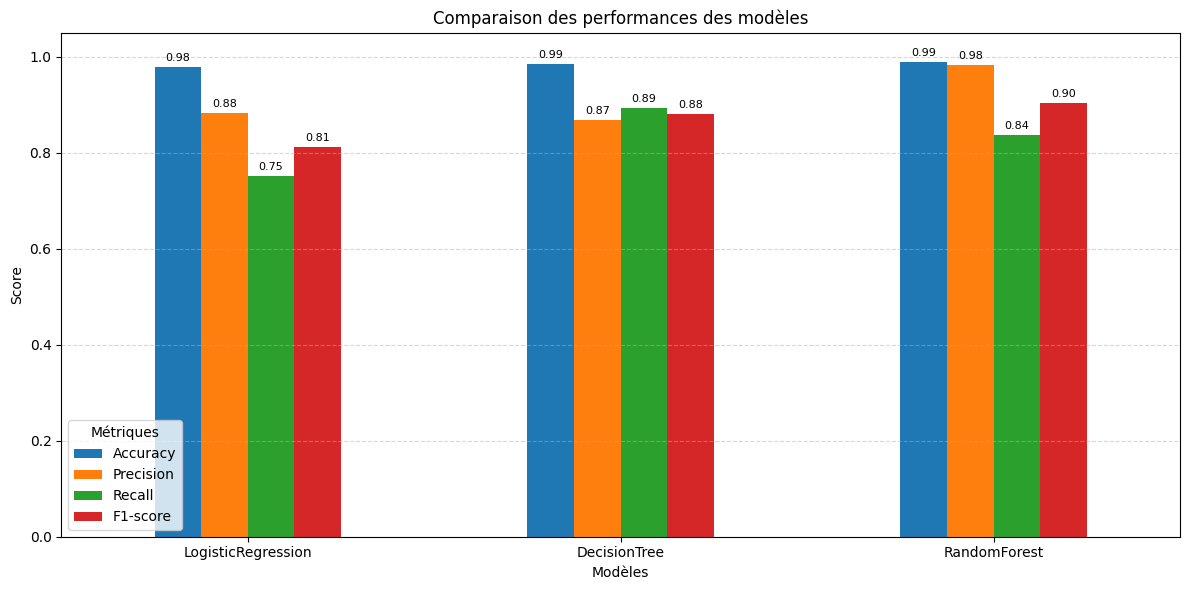

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Résultats des modèles
results_df = pd.DataFrame({
    "Modele": ["LogisticRegression", "DecisionTree", "RandomForest"],
    "Accuracy": [0.978546, 0.985114, 0.989054],
    "Precision": [0.883333, 0.868966, 0.983333],
    "Recall": [0.751773, 0.893617, 0.836879],
    "F1-score": [0.812261, 0.881119, 0.904215]
})

# Mettre le nom du modèle en index
results_df = results_df.set_index("Modele")

# Création du graphique
ax = results_df.plot(kind="bar", figsize=(12, 6))

# Mise en forme
plt.title("Comparaison des performances des modèles")
plt.xlabel("Modèles")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métriques")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Affichage des valeurs au-dessus des barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

### RandomForest : Apprentissage Supervisé

In [ ]:
import pandas as pd
import joblib

from google.colab import drive

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1) Monter Google Drive
# =========================
drive.mount('/content/drive')

# =========================
# 2) Charger le dataset
# =========================
input_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/Patrimoine_Arbore_data_clean_ia_avec_alerte.csv"
model_output_file = "/content/drive/MyDrive/Projet-BDD-IA-WEB/Systeme-alerte-tempetes/random_forest_alerte.pkl"

df = pd.read_csv(input_file, keep_default_na=False)

print("Colonnes du dataset :")
print(df.columns.tolist())

# =========================
# 3) Définir la cible
# =========================
TARGET_COL = "alerte"

if TARGET_COL not in df.columns:
    raise ValueError(f"La colonne cible '{TARGET_COL}' est introuvable.")

# =========================
# 4) Exclure les colonnes qui créent une fuite de données
# =========================
colonnes_a_exclure = [
    "alerte",
    "score_risque",
    "niveau_risque",
    "diam_mediane",
    "diam_q1",
    "haut_mediane",
    "haut_q3",
    "age_mediane",
    "age_q3"
]
colonnes_a_exclure = [col for col in colonnes_a_exclure if col in df.columns]

X = df.drop(columns=colonnes_a_exclure)
y = df[TARGET_COL]

print("\nRépartition de la cible :")
print(y.value_counts())
print(y.value_counts(normalize=True))

# =========================
# 5) Convertir les colonnes numériques
# =========================
colonnes_numeriques_attendues = ["haut_tot", "haut_tronc", "tronc_diam", "age_estim"]

for col in colonnes_numeriques_attendues:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# =========================
# 6) Identifier les colonnes numériques / catégorielles
# =========================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nColonnes numériques :")
print(numeric_features)

print("\nColonnes catégorielles :")
print(categorical_features)

# =========================
# 7) Prétraitement
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================
# 8) Split train / test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

# =========================
# 9) Pipeline RandomForest
# =========================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# =========================
# 10) Grille d'hyperparamètres
# =========================
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__class_weight": [None, "balanced"]
}

# =========================
# 11) GridSearchCV
# =========================
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# =========================
# 12) Meilleur modèle
# =========================
best_model = grid_search.best_estimator_

print("\nMeilleur modèle :")
print(best_model)

print("\nMeilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur score CV :")
print(grid_search.best_score_)

# =========================
# 13) Évaluation finale sur le test
# =========================
y_pred = best_model.predict(X_test)

print("\n===== Évaluation finale sur le jeu de test =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================
# 14) Sauvegarde en .pkl
# =========================
joblib.dump(best_model, model_output_file)

print("\nModèle sauvegardé dans :")
print(model_output_file)



# =========================
# 13) Évaluation finale sur le test
# =========================
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("\n===== Évaluation finale sur le jeu de test =====")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_test, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_test, zero_division=0))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_test))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test, zero_division=0))

# =========================
# 14) Vérification du sur-apprentissage
# =========================
print("\n=== Scores sur TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train, zero_division=0))
print("Recall   :", recall_score(y_train, y_pred_train, zero_division=0))
print("F1-score :", f1_score(y_train, y_pred_train, zero_division=0))

print("\n=== Scores sur TEST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_test, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_test, zero_division=0))

print("\n=== Validation croisée ===")
print("Best CV score :", grid_search.best_score_)

# =========================
# 15) Sauvegarde en .pkl
# =========================
joblib.dump(best_model, model_output_file)

print("\nModèle sauvegardé dans :")
print(model_output_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colonnes du dataset :
['haut_tot', 'haut_tronc', 'tronc_diam', 'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'age_estim', 'feuillage', 'haut_mediane', 'haut_q3', 'diam_mediane', 'diam_q1', 'age_mediane', 'age_q3', 'score_risque', 'niveau_risque', 'alerte']

Répartition de la cible :
alerte
0    10714
1      704
Name: count, dtype: int64
alerte
0    0.938343
1    0.061657
Name: proportion, dtype: float64

Colonnes numériques :
['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim']

Colonnes catégorielles :
['fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'feuillage']

Train : (9134, 10) (9134,)
Test  : (2284, 10) (2284,)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Meilleur modèle :
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                           